In [5]:
import numpy as np
import pandas as pd
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import ngrams
import re

import matplotlib.pyplot as plt

import string
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout, GRU , SimpleRNN

import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [6]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
df = pd.read_csv('combined_data.csv', on_bad_lines='skip', encoding='latin1')

In [8]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [9]:
df.shape

(83448, 2)

In [10]:
df['text'] = df['text'].str.lower()

In [11]:
def remove_special(text):
    return str(text).translate (str.maketrans('', '', string.punctuation))

df['text'] = df['text'].apply(remove_special)

In [12]:
Stops = set(stopwords.words('english'))

In [13]:
def  remove_stopwords(text):
  return [word for word in text if word not in Stops]

df['text'] = df['text'].apply(word_tokenize)
df['text'] = df['text'].apply(remove_stopwords)

In [14]:
df.head()

,label,text
0,1,"[ounce, feather, bowl, hummingbird, opec, mome..."
1,1,"[wulvob, get, medircations, online, qnb, ikud,..."
2,0,"[computer, connection, cnn, com, wednesday, es..."
3,1,"[university, degree, obtain, prosperous, futur..."
4,0,"[thanks, answers, guys, know, checked, rsync, ..."


In [15]:
def remove_hyperlink(text_list):
    cleaned_words = []
    for word in text_list:
        # Ensure each 'word' is converted to a string before applying regex
        cleaned_words.append(re.sub(r"http\S+", "", str(word)))
    return cleaned_words

df['text'] = df['text'].apply(remove_hyperlink)

In [16]:
import pandas as pd
import re
from collections import Counter

# Diagnose the issue with the 'label' column
print(f"Data type of 'label' column: {df['label'].dtype}")
print(f"Unique values in 'label' column: {df['label'].unique()}")

# 1. Filter only spam emails by comparing to the string '1'
spam_df = df[df['label'] == '1']

# 2. Combine all spam text into one string
# Ensure 'text' column is not empty for spam_df before joining
if not spam_df.empty:
    # The 'text' column contains lists of words, so we need to explode it first
    all_spam_text = " ".join(spam_df['text'].explode().astype(str))
else:
    all_spam_text = ""
    print("Warning: spam_df is empty, no spam text to process.")

# 3. Clean text (lowercase, remove special characters & numbers) - already handled by previous steps, but re-cleaning for robustness
all_spam_text = all_spam_text.lower()
all_spam_text = re.sub(r'[^a-z\s]', '', all_spam_text)

# 4. Split into words
words = all_spam_text.split()

# 5. Count word frequencies
word_freq = Counter(words)

# 6. Get Top 10 most common words
top_10_words = word_freq.most_common(10)

print("Top 10 most frequent words in SPAM emails:")
for word, freq in top_10_words:
    print(f"{word} : {freq}")

Data type of 'label' column: int64
Unique values in 'label' column: [1 0]
Top 10 most frequent words in SPAM emails:


In [17]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [18]:
max_features = 5000
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [19]:
average_length = sum(map(len, X_train_seq)) / len(X_train_seq)

In [20]:
max_length = 500
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length,padding = 'post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length,padding = 'post')

In [21]:
max_features = 5000
max_length = 500
embedding_length = 32

In [22]:
model_rnn = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),

    SimpleRNN(64),

    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_lstm = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),
    LSTM(64, use_cudnn=False),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
model_gru = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),

    GRU(64,use_cudnn=False),

    Dense(1, activation='sigmoid')
])

model_gru.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_gru.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
EPOCHS = 10
BATCH_SIZE = 64

In [26]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9563 - loss: 0.1197 - val_accuracy: 0.9798 - val_loss: 0.0652
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.9830 - loss: 0.0541 - val_accuracy: 0.9813 - val_loss: 0.0636
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9897 - loss: 0.0340 - val_accuracy: 0.9824 - val_loss: 0.0543
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9875 - loss: 0.0380 - val_accuracy: 0.9798 - val_loss: 0.0662
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9934 - loss: 0.0224 - val_accuracy: 0.9792 - val_loss: 0.0696
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.9849 - loss: 0.0481 - val_accuracy: 0.9339 - val_loss: 0.1747
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.9757 - loss: 0.0711 - val_accuracy: 0.9804 - val_loss: 0.0656
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9939 - loss: 0.0199 - 

In [32]:
import numpy as np

y_pred_prob = model_rnn.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

861/861 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step


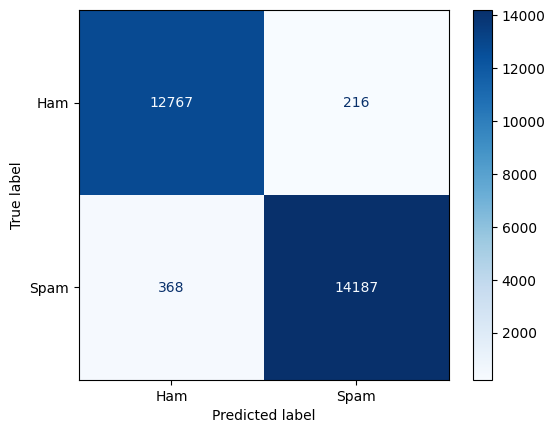

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)
disp.plot(cmap='Blues')
plt.show()

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     12983
           1       0.99      0.97      0.98     14555

    accuracy                           0.98     27538
   macro avg       0.98      0.98      0.98     27538
weighted avg       0.98      0.98      0.98     27538



In [27]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 48s 52ms/step - accuracy: 0.9640 - loss: 0.1073 - val_accuracy: 0.9815 - val_loss: 0.0570
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9847 - loss: 0.0523 - val_accuracy: 0.9822 - val_loss: 0.0530
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9883 - loss: 0.0398 - val_accuracy: 0.9828 - val_loss: 0.0538
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9910 - loss: 0.0315 - val_accuracy: 0.9840 - val_loss: 0.0535
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.9933 - loss: 0.0223 - val_accuracy: 0.9824 - val_loss: 0.0604
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9912 - loss: 0.0338 - val_accuracy: 0.9841 - val_loss: 0.0604
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.9954 - loss: 0.0174 - val_accuracy: 0.9831 - val_loss: 0.0637
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9950 - loss: 0.0172 - 

In [35]:
import numpy as np

y_pred_prob_lstm = model_lstm.predict(X_test_pad)
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int)

861/861 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step


In [36]:
from sklearn.metrics import accuracy_score

lstm_accuracy = accuracy_score(y_test, y_pred_lstm)
print("LSTM Accuracy:", lstm_accuracy)

LSTM Accuracy: 0.9845304669910669


In [37]:
from sklearn.metrics import classification_report

print("LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=["Ham", "Spam"]))

LSTM Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.98     12983
        Spam       0.98      0.99      0.99     14555

    accuracy                           0.98     27538
   macro avg       0.98      0.98      0.98     27538
weighted avg       0.98      0.98      0.98     27538



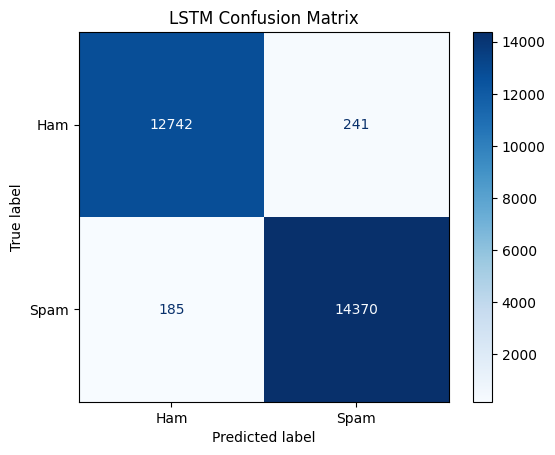

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lstm = confusion_matrix(y_test, y_pred_lstm)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=["Ham", "Spam"]
).plot(cmap="Blues")

plt.title("LSTM Confusion Matrix")
plt.show()

In [39]:
history_gru = model_gru.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 56s 58ms/step - accuracy: 0.9626 - loss: 0.1057 - val_accuracy: 0.9814 - val_loss: 0.0592
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 48s 55ms/step - accuracy: 0.9871 - loss: 0.0443 - val_accuracy: 0.9858 - val_loss: 0.0488
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 48s 55ms/step - accuracy: 0.9911 - loss: 0.0316 - val_accuracy: 0.9817 - val_loss: 0.0709
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 48s 55ms/step - accuracy: 0.9941 - loss: 0.0216 - val_accuracy: 0.9860 - val_loss: 0.0509
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 48s 54ms/step - accuracy: 0.9948 - loss: 0.0193 - val_accuracy: 0.9849 - val_loss: 0.0518
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 48s 55ms/step - accuracy: 0.9955 - loss: 0.0159 - val_accuracy: 0.9839 - val_loss: 0.0575
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 48s 55ms/step - accuracy: 0.9971 - loss: 0.0094 - val_accuracy: 0.9845 - val_loss: 0.0567
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 48s 55ms/step - accuracy: 0.9975 - loss: 0.0091 - 

In [40]:
y_pred_prob_gru = model_gru.predict(X_test_pad)
y_pred_gru = (y_pred_prob_gru > 0.5).astype(int)

861/861 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step


In [41]:
gru_accuracy = accuracy_score(y_test, y_pred_gru)
print("GRU Accuracy:", gru_accuracy)

GRU Accuracy: 0.9838768247512528


In [42]:
print("GRU Classification Report:")
print(classification_report(y_test, y_pred_gru, target_names=["Ham", "Spam"]))

GRU Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.98      0.98     12983
        Spam       0.99      0.98      0.98     14555

    accuracy                           0.98     27538
   macro avg       0.98      0.98      0.98     27538
weighted avg       0.98      0.98      0.98     27538



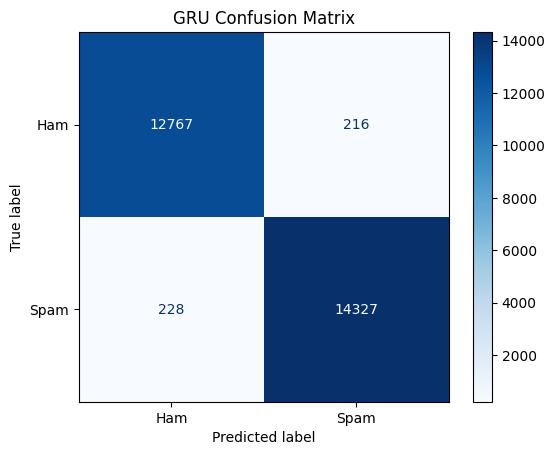

In [43]:
cm_gru = confusion_matrix(y_test, y_pred_gru)

ConfusionMatrixDisplay(
    confusion_matrix=cm_gru,
    display_labels=["Ham", "Spam"]
).plot(cmap="Blues")

plt.title("GRU Confusion Matrix")
plt.show()


In [44]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

def evaluate_model(model, X_test, y_test, model_name):
    y_prob = model.predict(X_test)
    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Spam Precision": report["1"]["precision"],
        "Spam Recall": report["1"]["recall"],
        "Spam F1": report["1"]["f1-score"]
    }


In [45]:
results = []

results.append(evaluate_model(model_rnn, X_test_pad, y_test, "Simple RNN"))
results.append(evaluate_model(model_lstm, X_test_pad, y_test, "LSTM"))
results.append(evaluate_model(model_gru, X_test_pad, y_test, "GRU"))

results_df = pd.DataFrame(results)
print(results_df)


861/861 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
861/861 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
861/861 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
        Model  Accuracy  Spam Precision  Spam Recall   Spam F1
0  Simple RNN  0.978793        0.985003     0.974717  0.979833
1        LSTM  0.984530        0.983506     0.987290  0.985394
2         GRU  0.983877        0.985147     0.984335  0.984741


In [46]:
best_model_row = results_df.sort_values(
    by="Spam F1",
    ascending=False
).iloc[0]

print("Best Model:")
print(best_model_row)

Best Model:
Model                 LSTM
Accuracy           0.98453
Spam Precision    0.983506
Spam Recall        0.98729
Spam F1           0.985394
Name: 1, dtype: object


In [47]:
model_gru.save("gru_model.keras")

In [48]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [49]:
config = {
    "max_features": max_features,
    "max_length": max_length,
    "embedding_length": embedding_length
}

with open("config.pkl", "wb") as f:
    pickle.dump(config, f)

In [50]:
label_mapping = {0: "Ham", 1: "Spam"}

with open("label_mapping.pkl", "wb") as f:
    pickle.dump(label_mapping, f)